<a href="https://colab.research.google.com/github/itseriqq/natural-language-processing/blob/main/Projeto_Pr%C3%A1tico_PLN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Processamento de Linguagem Natural [2025-Q3]**
Prof. Alexandre Donizeti Alves

### **PROJETO PRÁTICO** [LangChain + Grandes Modelos de Linguagem]


O **PROJETO PRÁTICO** deve ser feito utilizando o **Google Colab** com uma conta sua vinculada ao Gmail. O link do seu notebook armazenado no Google Drive e o link de um repositório no GitHub devem ser enviados usando o seguinte formulário:

> https://forms.gle/D4gLqP1iGgyn2hbH8


**IMPORTANTE**: A submissão deve ser feita até o dia **07/12 (domingo)** APENAS POR UM INTEGRANTE DA EQUIPE, até às 23h59. Por favor, lembre-se de dar permissão de ACESSO IRRESTRITO para o professor da disciplina.

### **EQUIPE**

---

**POR FAVOR, PREENCHER OS INTEGRANDES DA SUA EQUIPE:**


**Integrante 01:**

`Erick Augusto Silva Pereira - RA: 11202130310`

**Integrante 02:**

`Victor Ravazio de Lima - RA: 11201920941`

### **GRANDE MODELO DE LINGUAGEM (*Large Language Model - LLM*)**

---

Cada equipe deve selecionar um Grande Modelo de Linguagem (*Large Language Model - LMM*).



Por favor, informe os dados do LLM selecionada:

>


**LLM**: Gemini (Modelo Flash)

>

**Link para a documentação oficial**: https://ai.google.dev/gemini-api/docs/



### **API (Opcional)**
---

Por favor, informe os dados da API selecionada:

**API**: TwitterApi.io

**Site oficial**: https://twitterapi.io/

**Link para a documentação oficial**: https://docs.twitterapi.io/introduction






### **DESCRIÇÃO**
---

Implementar um `notebook` no `Google Colab` que faça uso do framework **`LangChain`** (obrigatório) e de um **LLM** aplicando, no mínimo, DUAS técnicas de PLN. As técnicas podem ser aplicada em qualquer córpus obtido a partir de uma **API** ou a partir de uma página Web.

O **LLM** e a **API** selecionados devem ser informados na seguinte planilha:

> https://docs.google.com/spreadsheets/d/1iIUZcwnywO7RuF6VEJ8Rx9NDT1cwteyvsnkhYr0NWtU/edit?usp=sharing

>
As seguintes técnicas de PLN podem ser usadas:

*   Correção Gramatical
*   Classificação de Textos
*   Análise de Sentimentos
*   Detecção de Emoções
*   Extração de Palavras-chave
*   Tradução de Textos
*   Sumarização de Textos
*   Similaridade de Textos
*   Reconhecimento de Entidades Nomeadas
*   Sistemas de Perguntas e Respostas
>

**IMPORTANTE:** É obrigatório usar o e-mail da UFABC.


### **CRITÉRIOS DE AVALIAÇÃO**
---


Serão considerados como critérios de avaliação os seguintes pontos:

* Uso do framework **`LangChain`**.

* Escolha e uso de um **LLM**.

* Escolha e uso de uma **API** ou **Página Web**.

* Projeto disponível no Github.

* Apresentação (5 a 10 minutos).

* Criatividade no uso do framework **`LangChain`** em conjunto com o **LLM** e a **API**.




**IMPORTANTE**: todo o código do notebook deve ser executado. Código sem execução não será considerado.

### **IMPLEMENTAÇÃO**
---

In [7]:
# alternativamente, estamos deixando o arquivo caso seja necessario dado que a API tem limite de uso para $0.10 centavos. Os créditos são limitados. O arquivo possui
# 18 replies (1 página somente) ao tweet (https://x.com/elonmusk/status/1965860002545152203)
# de ID: 1965860002545152203 do elon musk

import json

filename = 'replies.json'

with open(filename, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Supondo que cada tweet está em data["tweets"]
textos = [tweet["text"] for tweet in data["tweets"]]

# Exemplo de impressão
for texto in textos:
    print(texto)


@elonmusk Whoever the shooter may be, the only good thing they managed to do was save us from a president Kirk in 2040.
@elonmusk What is the TRUTH about his death?
@FoundersEcho @mandala_mandy @elonmusk You have a problem with God's will? 

Satanist
@elonmusk @Davidharris_9 😭
@elonmusk @fatherdoge4207 He died instantly assclown!
@Shadow_Vx88 @PookiesParadise @elonmusk Low IQ opinion.

Now turn to the left
@elonmusk It was not comparable with life. Too much damage.😢 so full of life and promise. Amazing young man. Gone in an instant. Irreplaceable 🤦🏼‍♀️ 💔
@JimEagleUC @PookiesParadise @elonmusk if ur logic is correct, everyone and I mean everyone would die, there will never be one thing that every human being can agree upon. Not to mention, that every person has a different idea of what's right and what's wrong, End topic.
@elonmusk @saxsonmusk5 😭😭😭🙏🏻✨
@elonmusk Much more better
@elonmusk @youngchris_0852 Sorry !
@JacksonDann @elonmusk Well think about context first before you consider w

In [101]:
import requests
import time
from google.colab import userdata

api_key = userdata.get('twitterApi')
tweet_id = '1965860002545152203'  # ID do tweet
max_pages = 2  # número máximo de páginas a buscar

headers = {
    'X-API-Key': api_key,
    'Accept': 'application/json',
}

all_texts = []
cursor = ""
page_count = 0

while page_count < max_pages:
    # Monta URL incluindo cursor só se não for vazio
    if cursor:
        url = f'https://api.twitterapi.io/twitter/tweet/replies?tweetId={tweet_id}&cursor={cursor}'
    else:
        url = f'https://api.twitterapi.io/twitter/tweet/replies?tweetId={tweet_id}'

    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        print(f'Erro {response.status_code}: {response.text}')
        break

    data = response.json()
    tweets = data.get("tweets", [])
    textos = [tweet["text"] for tweet in tweets]
    all_texts.extend(textos)

    page_count += 1

    if data.get("has_next_page", False):
        cursor = data.get("next_cursor", "")
        time.sleep(6)  # aguarda 6 segundos antes da próxima requisição
    else:
        break

print(f'Total de páginas buscadas: {page_count}')
print(f"Quantidade total de tweets: {len(all_texts)}")
for i, texto in enumerate(all_texts, 1):
    print(f"Tweet {i}: {texto}\n")


Total de páginas buscadas: 2
Quantidade de tweets na resposta: 36
@elonmusk Whoever the shooter may be, the only good thing they managed to do was save us from a president Kirk in 2040.
@elonmusk What is the TRUTH about his death?
@FoundersEcho @mandala_mandy @elonmusk You have a problem with God's will? 

Satanist
@elonmusk @Davidharris_9 😭
@elonmusk @fatherdoge4207 He died instantly assclown!
@Shadow_Vx88 @PookiesParadise @elonmusk Low IQ opinion.

Now turn to the left
@elonmusk It was not comparable with life. Too much damage.😢 so full of life and promise. Amazing young man. Gone in an instant. Irreplaceable 🤦🏼‍♀️ 💔
@JimEagleUC @PookiesParadise @elonmusk if ur logic is correct, everyone and I mean everyone would die, there will never be one thing that every human being can agree upon. Not to mention, that every person has a different idea of what's right and what's wrong, End topic.
@elonmusk @saxsonmusk5 😭😭😭🙏🏻✨
@elonmusk Much more better
@elonmusk @youngchris_0852 Sorry !
@JacksonD

In [112]:
from google import genai
from google.colab import userdata

client = genai.Client(api_key=userdata.get('keyGemini'))

def avaliar_sentimento(texto):
    prompt = (
        f'Avalie o sentimento do seguinte tweet. '
        f'Classifique como \"positivo\", \"negativo\", \"neutro\" ou \"indefinido\". '
        f'Retorne na seguinte forma: categoria; sentimento. '
        f'Classifique como \"felicidade\", \"tristeza\", \"raiva\", \"ironia\", \"angústia\", \"dúvida\", \"nojo\", \"medo\", \"surpresa\", \"desprezo\", \"desejo\", \"decepção\", \"tédio\" ou \"indefinido\". '
        f'Exemplo: positivo; felicidade, tristeza, raiva, ironia, angústia.'
        f'Não retorne texto adicional. Tweet: {texto}'
    )
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )
    return response.text.strip()

resultados_sentimentos = []

for tweet in all_texts:
    resposta = avaliar_sentimento(tweet)
    partes = resposta.split(';')
    if len(partes) == 2:
        categoria = partes[0].strip().lower()
        sentimentos_str = partes[1].strip().lower()
        sentimentos = [s.strip() for s in sentimentos_str.split(',')]
    else:
        categoria = "indefinido"
        sentimentos = []

    resultados_sentimentos.append({
        "tweet": tweet,
        "categoria": categoria,
        "sentimentos": sentimentos
    })


In [104]:
print(resultados_sentimentos)

[{'tweet': '@elonmusk Whoever the shooter may be, the only good thing they managed to do was save us from a president Kirk in 2040.', 'categoria': 'negativo', 'sentimentos': ['ironia', 'desprezo', 'raiva']}, {'tweet': '@elonmusk What is the TRUTH about his death?', 'categoria': 'negativo', 'sentimentos': ['dúvida', 'desejo', 'angústia']}, {'tweet': "@FoundersEcho @mandala_mandy @elonmusk You have a problem with God's will? \n\nSatanist", 'categoria': 'negativo', 'sentimentos': ['raiva', 'desprezo']}, {'tweet': '@elonmusk @Davidharris_9 😭', 'categoria': 'negativo', 'sentimentos': ['angústia']}, {'tweet': '@elonmusk @fatherdoge4207 He died instantly assclown!', 'categoria': 'negativo', 'sentimentos': ['raiva', 'desprezo']}, {'tweet': '@Shadow_Vx88 @PookiesParadise @elonmusk Low IQ opinion.\n\nNow turn to the left', 'categoria': 'negativo', 'sentimentos': ['raiva', 'desprezo']}, {'tweet': '@elonmusk It was not comparable with life. Too much damage.😢 so full of life and promise. Amazing yo

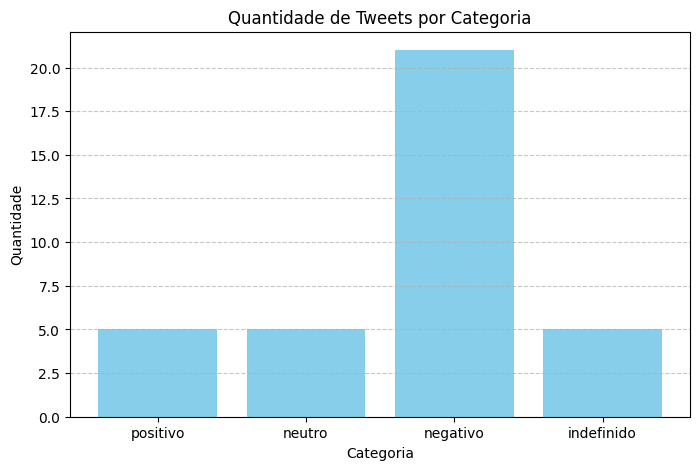

In [113]:
import matplotlib.pyplot as plt
from collections import Counter

# Contagem de categorias
contagem_categorias = Counter(item["categoria"] for item in resultados_sentimentos)

plt.figure(figsize=(8, 5))
plt.bar(contagem_categorias.keys(), contagem_categorias.values(), color='skyblue')
plt.title("Quantidade de Tweets por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Quantidade")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


/tmp/ipython-input-1106984570.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=labels, palette="viridis")


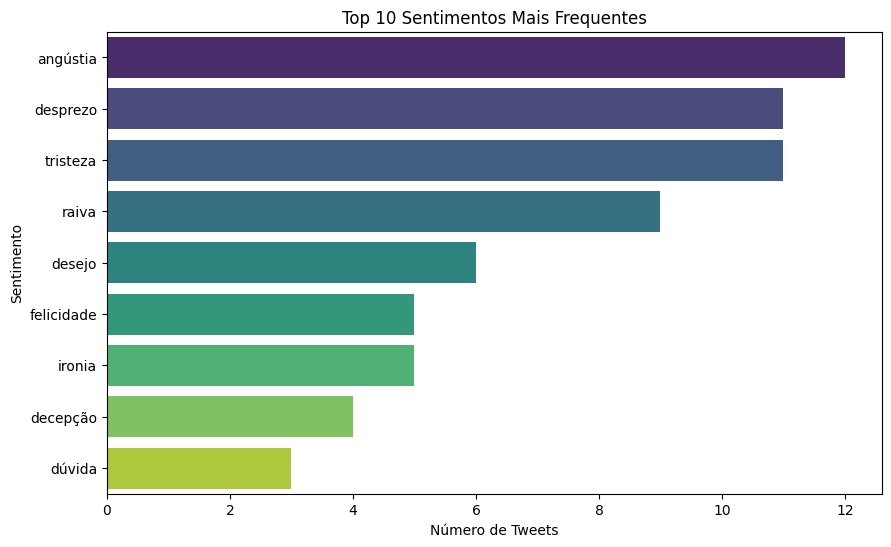

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import chain

# Substituir sentimento vazio por "indefinido"
listas_de_sentimentos = [
    item["sentimentos"] if item["sentimentos"] else ["indefinido"]
    for item in resultados_sentimentos
]

todos_sentimentos = list(chain.from_iterable(listas_de_sentimentos))

contagem_sentimentos = Counter(todos_sentimentos)
mais_comuns = contagem_sentimentos.most_common(10)

# Remove "indefinido" do gráfico
mais_comuns = [item for item in mais_comuns if item[0] != "indefinido"]

if mais_comuns:
    labels, counts = zip(*mais_comuns)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=counts, y=labels, palette="viridis")
    plt.title("Top 10 Sentimentos Mais Frequentes")
    plt.xlabel("Número de Tweets")
    plt.ylabel("Sentimento")
    plt.show()
else:
    print("Não há sentimentos válidos para plotar.")


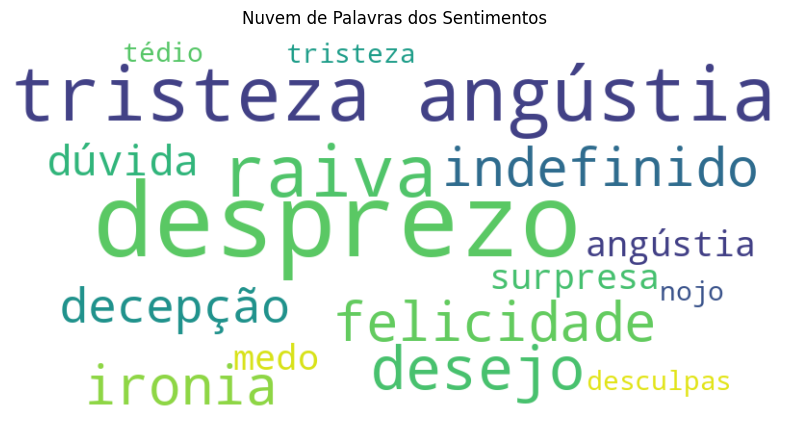

In [115]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join([' '.join(s) for s in [item["sentimentos"] for item in resultados_sentimentos if item["sentimentos"]]])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras dos Sentimentos')
plt.show()


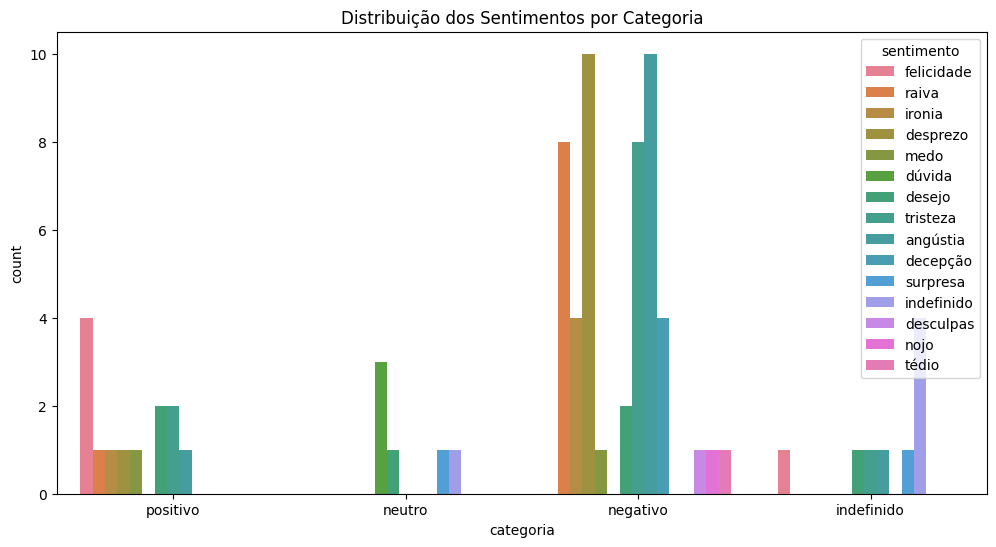

In [116]:
import pandas as pd
import seaborn as sns

# Montar dataframe para plot
df = pd.DataFrame([
    {"categoria": item["categoria"], "sentimento": s}
    for item in resultados_sentimentos for s in item["sentimentos"]
])

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='categoria', hue='sentimento')
plt.xticks(rotation=0)
plt.title("Distribuição dos Sentimentos por Categoria")
plt.show()
